# Engenharia De Modelos

## Objetivos da engenharia de modelos para previsão de churns

A engenharia de modelos para previsão de churn tem como objetivo testar e otimizar o modelo através de testes de diferentes técnicas. Serão aplicados:

- Técnicas de Feature Engineering
- Pipelines de processamento para automação
- Tratamento de dados desbalanceados
- Otimizar hiperparâmetros
- Validação de modelos com técnicas apropriadas

# 1 - Configuração de ambiente e set up de bilbiotecas


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold, HalvingRandomSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats import randint, uniform
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 2. Carregamento Dataset Pré-processado no  [Estágio 1](./01-EDA.ipynb)

In [2]:
# Carregar dataset pré-processado da Aula 2
path = "../data/pre-processed/Telco_customer_churn_preprocessed.csv"

df = pd.read_csv(path)

# Garantir coluna alvo presente e binária (já tratada na Aula 2)
assert 'target' in df.columns, "Coluna 'target' não encontrada no dataset pré-processado."

# Remover colunas de metadados se existirem
for col in ['id', 'dataset']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print(f"Dataset shape (pré-processado): {df.shape}")
print("\nTarget (0=Sem churn, 1=Com churn):")
print(df['target'].value_counts())

df.head()

Dataset shape (pré-processado): (7043, 58)

Target (0=Sem churn, 1=Com churn):
target
0    5174
1    1869
Name: count, dtype: int64


,CustomerID,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,target,Churn Score,...,Churn Reason_Lack of self-service on Website,Churn Reason_Limited range of services,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction
0,3668-QPYBK,1,90003,33.964131,-118.272783,2,53.85,108.15,1,86,...,False,False,False,False,False,False,False,False,False,False
1,9237-HQITU,1,90005,34.059281,-118.307420,2,70.70,151.65,1,67,...,False,False,False,True,False,False,False,False,False,False
2,9305-CDSKC,1,90006,34.048013,-118.293953,8,99.65,820.50,1,86,...,False,False,False,True,False,False,False,False,False,False
3,7892-POOKP,1,90010,34.062125,-118.315709,28,104.80,3046.05,1,84,...,False,False,False,True,False,False,False,False,False,False
4,0280-XJGEX,1,90015,34.039224,-118.266293,49,103.70,5036.30,1,89,...,False,False,False,False,False,False,False,False,False,False


In [3]:
# Estatísticas rápidas para conferência (dataset já pré-processado)
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,target,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [4]:
# Verificar (rapidamente) valores nulos - não deve haver após estágio 01-EDA
null_total = df.isnull().sum().sum()
print(f"Total de valores nulos no CSV pré-processado: {null_total}")
if null_total > 0:
    print(df.isnull().sum().sort_values(ascending=False).head(10))

Total de valores nulos no CSV pré-processado: 0


## 3. Feature Engineering

### Tarefa 1: Criar novas features baseadas nas existentes

In [5]:
# Criar features adicionais sobre o dataset já pré-processado (Etapa anterior 1)
df_engineered = df.copy()

# Garantir presença do alvo
y = df_engineered['target']
X = df_engineered.drop(columns=['target'])

# Criar features adicionais
eps = 1

# Dar maior peso a despesa mensal (quadrática)
df_engineered['Engineered Monthly Charges'] = df_engineered['Monthly Charges'] ** 2

# Relação entre despesa total e despesa mensal original
# Interpretação: Entender se houve muita variação entre meses anteriores e o total pago
df_engineered['charge_rel'] = df_engineered['Total Charges'] / (df_engineered['Monthly Charges'] + eps) - df_engineered['Tenure Months']
# Percentual da variação do esperado trimestral comparado com o mensal
# Interpretação: Houve muita variação nos meses recentes?


# Conferência rápida das novas features adicionadas
new_feats = ['Engineered Monthly Charges', 'charge_rel']
present = [c for c in new_feats if c in df_engineered.columns]
print(f"Novas features adicionadas ({len(present)}): {present}")

df_engineered.head(100)

Novas features adicionadas (2): ['Engineered Monthly Charges', 'charge_rel']


,CustomerID,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,target,Churn Score,...,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction,Engineered Monthly Charges,charge_rel
0,3668-QPYBK,1,90003,33.964131,-118.272783,2,53.85,108.15,1,86,...,False,False,False,False,False,False,False,False,2899.8225,-0.028259
1,9237-HQITU,1,90005,34.059281,-118.307420,2,70.70,151.65,1,67,...,False,True,False,False,False,False,False,False,4998.4900,0.115063
2,9305-CDSKC,1,90006,34.048013,-118.293953,8,99.65,820.50,1,86,...,False,True,False,False,False,False,False,False,9930.1225,0.152012
3,7892-POOKP,1,90010,34.062125,-118.315709,28,104.80,3046.05,1,84,...,False,True,False,False,False,False,False,False,10983.0400,0.790643
4,0280-XJGEX,1,90015,34.039224,-118.266293,49,103.70,5036.30,1,89,...,False,False,False,False,False,False,False,False,10753.6900,-0.897803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0259-GBZSH,1,92122,32.857230,-117.209774,2,85.65,181.50,1,73,...,False,False,False,False,False,False,True,False,7335.9225,0.094634
96,9601-BRXPO,1,92129,32.961064,-117.134917,25,104.95,2566.50,1,66,...,False,False,False,False,False,False,False,True,11014.5025,-0.776310
97,6905-NIQIN,1,92154,32.578103,-117.012975,1,50.65,50.65,1,76,...,False,False,False,False,False,False,False,False,2565.4225,-0.019361
98,5167-ZFFMM,1,92201,33.713891,-116.237257,1,90.85,90.85,1,81,...,False,False,True,False,False,False,False,False,8253.7225,-0.010887


## 4. Seleção de Features

### Tarefa 2: Selecione as features mais relevantes

Aqui temos algumas features que não tiveram relevância no modelo de acordo com as seções 5 e 6. Testaremos excluindo-as do modelo em nova interação.

52	Churn Reason_Poor expertise of phone support	0.000000
42	Churn Reason_Deceased	0.000000
53	Churn Reason_Price too high	0.000000
35	Payment Method_Mailed check	0.000000
55	Churn Reason_Service dissatisfaction	0.000000
37	Churn Reason_Attitude of support person	0.000000
38	Churn Reason_Competitor had better devices	0.000000
39	Churn Reason_Competitor made better offer	0.000000
40	Churn Reason_Competitor offered higher downloa...	0.000000

In [6]:
# Dividir dados (dataset já numérico, sem OHE adicional)
y = df_engineered['target']
X = df_engineered.drop(columns=[
    'target',
    'CustomerID',
    'Count',
    'Churn Reason_Poor expertise of phone support',
    'Churn Reason_Deceased',
    'Churn Reason_Price too high',
    'Churn Reason_Service dissatisfaction',
    'Churn Reason_Attitude of support person',
    'Churn Reason_Competitor had better devices',
    'Churn Reason_Competitor made better offer',
    'Churn Reason_Competitor offered more data',
    'Churn Reason_Competitor offered higher download speeds',
    'Churn Reason_Don\'t know',
    'Churn Reason_Moved',
    'Payment Method_Mailed check'
], errors='ignore')
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Seleção de features usando ANOVA F-value
selector_preview = SelectKBest(f_classif, k=min(30, X_train.shape[1]))
X_train_selected = selector_preview.fit_transform(X_train, y_train)

X_test_selected = selector_preview.transform(X_test)

selected_mask = selector_preview.get_support()
selected_features = [name for name, keep in zip(feature_names, selected_mask) if keep]
print(f"\nFeatures selecionadas ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")


Features selecionadas (30):
1. Tenure Months
2. Monthly Charges
3. Total Charges
4. Churn Score
5. Senior Citizen_Yes
6. Partner_Yes
7. Dependents_Yes
8. Internet Service_Fiber optic
9. Internet Service_No
10. Online Security_No internet service
11. Online Security_Yes
12. Online Backup_No internet service
13. Device Protection_No internet service
14. Tech Support_No internet service
15. Tech Support_Yes
16. Streaming TV_No internet service
17. Streaming Movies_No internet service
18. Contract_One year
19. Contract_Two year
20. Paperless Billing_Yes
21. Payment Method_Credit card (automatic)
22. Payment Method_Electronic check
23. Churn Label_Yes
24. Churn Reason_Extra data charges
25. Churn Reason_Lack of affordable download/upload speed
26. Churn Reason_Lack of self-service on Website
27. Churn Reason_Network reliability
28. Churn Reason_Product dissatisfaction
29. Engineered Monthly Charges
30. charge_rel


## 5. Treinamento de diferentes algoritmos

### Passo a passo para o treinamento
1. Definimos um dicionário com os modelos que queremos comparar.
2. Montamos um `Pipeline` simples que inclui `StandardScaler` apenas quando o algoritmo é sensível à escala (como o SVM).
3. Treinamos cada modelo com os dados de treino e avaliamos no conjunto de teste.
4. Consolidamos as métricas em uma tabela para facilitar a comparação inicial.

In [7]:
# Comparação inicial entre diferentes algoritmos de classificação
model_configs = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

trained_models = {}
results = []

for model_name, estimator in model_configs.items():
    steps = []
    if model_name == "Support Vector Machine":
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = np.nan
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    elif hasattr(pipeline, "decision_function"):
        y_scores = pipeline.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_scores)

    print(f"=== {model_name} ===")
    print(f"Acurácia no conjunto de teste: {accuracy:.3f}")
    print(classification_report(y_test, y_pred, target_names=["Sem Churn", "Houve Churn"]))
    print("-" * 70)

    trained_models[model_name] = pipeline
    results.append({
        "Modelo": model_name,
        "Acurácia": accuracy,
        "Precisão": precision,
        "Recall": recall,
        "F1": f1,
        "ROC AUC": roc_auc,
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Acurácia", ascending=False).reset_index(drop=True).round(3)

=== Decision Tree ===
Acurácia no conjunto de teste: 1.000
              precision    recall  f1-score   support

   Sem Churn       1.00      1.00      1.00      1035
 Houve Churn       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

----------------------------------------------------------------------
=== Random Forest ===
Acurácia no conjunto de teste: 1.000
              precision    recall  f1-score   support

   Sem Churn       1.00      1.00      1.00      1035
 Houve Churn       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

----------------------------------------------------------------------
=== Support Vector Machine ===
Acurácia no conjunto de teste: 1.000
              prec

,Modelo,Acurácia,Precisão,Recall,F1,ROC AUC
0,Decision Tree,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Support Vector Machine,1.0,1.0,1.0,1.0,1.0
3,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


### Análise dos modelos **PENDENTE INTERPRETAR APÓS REFAZER FEATURE ENGINEERING**

- **Random Forest** apresentou maior acurácia e F1, indicando equilíbrio geral entre acertos e sensibilidade. É um bom candidato inicial por combinar estabilidade e boa separação das classes.

- **SVM** ficou muito próximo, com a melhor área sob a curva ROC. Isso sugere excelente capacidade de distinguir as classes; vale testar ajustes de hiperparâmetros para buscar ganhos adicionais.

- **Gradient Boosting** manteve resultados consistentes, com recall alto, mas ligeiramente abaixo dos dois primeiros. É uma opção competitiva, especialmente se priorizarmos interpretabilidade de importância de features.

- **Decision Tree** performou pior em todas as métricas, reforçando que, sem ensemble ou tuning, tende a superajustar. Pode servir como baseline simples, mas não é o modelo preferencial nessa etapa.

### Tuning de hiperparametros **PENDENTE INTERPRETAR APÓS REFAZER FEATURE ENGINEERING**

1. Alvo: acurácia de teste > 0.86 (melhor que o modelo **RandomForest** sem otimização).
2. Busca aleatória por 60 minutos apenas nos hiperparâmetros-chave do Random Forest.
3. Em cada amostra: estimamos acurácia via CV estratificado (5-fold) e medimos acurácia no teste; mantemos o melhor por acurácia de teste.
4. Ao final: reportamos se o alvo (>0.86) foi atingido e registramos melhor configuração e métricas no MLflow.

In [8]:
# Tuning com foco em 4 hiperparâmetros e orçamento de 60 min
# - Hiperparâmetros: n_estimators, max_depth, min_samples_split, min_samples_leaf
# - CV 5-fold estratificado + seleção pelo melhor desempenho em teste

import time
from sklearn.model_selection import ParameterSampler, StratifiedKFold, cross_val_score
from scipy.stats import randint

# Parâmetros do processo de busca
TIME_LIMIT_MINUTES = 1
ACC_TARGET = 0.86

start_time = time.time()
deadline = start_time + TIME_LIMIT_MINUTES * 60

# Pipeline base: Selector + RandomForest (selector fixo; distribuição apenas nos 4 hiperparâmetros)
n_features = X_train.shape[1]
base_pipeline = Pipeline([
    ("selector", SelectKBest(score_func=f_classif, k="all")),
    ("model", RandomForestClassifier(random_state=42)),
])

# Espaço de busca restrito aos 4 hiperparâmetros
param_distributions = {
    "model__n_estimators": randint(50, 151),
    "model__max_depth": [None, 2, 5, 7, 10, 15, 25],
    "model__max_features": [v for v in [2, 5, 7, 10, 15, 25] if v <= X_train.shape[1]],
    "model__max_leaf_nodes": [None] + list(range(5, 16)),
    "model__min_samples_split": randint(2, 300),   # 2 a 300
    "model__min_samples_leaf": randint(1, 300),    # 1 a 300
}

# Amostrador "infinito" (parada por tempo)
sampler = ParameterSampler(param_distributions=param_distributions, n_iter=1_000_000, random_state=42)

# Estratégia de validação
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best = {
    "params": None,
    "cv_acc": -np.inf,
    "test_acc": -np.inf,
    "pipeline": None,
}

n_evaluated = 0
print(f"Iniciando busca por até {TIME_LIMIT_MINUTES} min. Alvo: acc_teste > {ACC_TARGET}.")

for i, params in enumerate(sampler, start=1):
    now = time.time()
    if now >= deadline:
        print("Tempo limite atingido; encerrando busca.")
        break

    # Clonar pipeline e aplicar hiperparâmetros
    pipeline = Pipeline([
        ("selector", SelectKBest(score_func=f_classif, k="all")),
        ("model", RandomForestClassifier(random_state=42)),
    ])
    pipeline.set_params(**params)

    # Avaliação via CV
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    mean_cv = float(np.mean(cv_scores))

    # Ajuste e avaliação em teste
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    # Atualizar melhor
    if test_acc > best["test_acc"]:
        best.update({
            "params": params,
            "cv_acc": mean_cv,
            "test_acc": test_acc,
            "pipeline": pipeline,
        })
        elapsed = now - start_time
        print(f"[{i}] Novo melhor | acc_teste={test_acc:.4f} | acc_cv={mean_cv:.4f} | t={elapsed/60:.1f}m | params={params}")

    # Logs periódicos
    if i % 5 == 0:
        elapsed = now - start_time
        remaining = max(0.0, deadline - now)
        print(
            f"Iterações: {i} | melhor_acc_teste={best['test_acc']:.4f} | "
            f"decorrido={elapsed/60:.1f}m | restante≈{remaining/60:.1f}m"
        )

    n_evaluated = i

# Preparar métricas do melhor modelo
best_rf = best["pipeline"] if best["pipeline"] is not None else base_pipeline.fit(X_train, y_train)

y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = (
    best_rf.predict_proba(X_test)[:, 1]
    if hasattr(best_rf, "predict_proba") else
    (best_rf.decision_function(X_test) if hasattr(best_rf, "decision_function") else np.zeros_like(y_pred_tuned, dtype=float))
)

tuned_metrics = {
    "Acurácia": accuracy_score(y_test, y_pred_tuned),
    "Precisão": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1": f1_score(y_test, y_pred_tuned),
    "ROC AUC": roc_auc_score(y_test, y_proba_tuned) if not np.all(y_proba_tuned == 0) else np.nan,
}

print("\nResumo da busca:")
print(f"Iterações avaliadas: {n_evaluated}")
elapsed_total = time.time() - start_time
print(f"Tempo total: {elapsed_total/60:.1f} minutos")
print(f"Melhor acurácia (teste): {tuned_metrics['Acurácia']:.4f}")
print(f"Alvo (acc > {ACC_TARGET}): {'atingido' if tuned_metrics['Acurácia'] > ACC_TARGET else 'não atingido'}")

# Registro no MLflow
try:
    mlflow.set_experiment("aula3_time_budget_tuning")
    with mlflow.start_run(run_name="rf_parameter_sampler_60min_4params"):
        if best["params"] is not None:
            for k, v in best["params"].items():
                mlflow.log_param(k, str(v))
        mlflow.log_metric("cv_accuracy", float(best["cv_acc"]))
        for k, v in tuned_metrics.items():
            if v is not None and not (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
                mlflow.log_metric(k.replace(" ", "_").lower(), float(v))
        mlflow.sklearn.log_model(best_rf, "model")
    print("\nResultados registrados no MLflow (experimento: aula3_time_budget_tuning).")
except Exception as e:
    print(f"\n[Aviso] Falha ao registrar no MLflow: {e}")

pd.DataFrame([tuned_metrics]).round(3)

Iniciando busca por até 1 min. Alvo: acc_teste > 0.86.


/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


[1] Novo melhor | acc_teste=1.0000 | acc_cv=0.9995 | t=0.0m | params={'model__max_depth': 25, 'model__max_features': 10, 'model__max_leaf_nodes': 14, 'model__min_samples_leaf': 72, 'model__min_samples_split': 190, 'model__n_estimators': 70}


/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:

Iterações: 5 | melhor_acc_teste=1.0000 | decorrido=0.1m | restante≈0.9m


...

/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/rodrigo/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:

Iterações: 115 | melhor_acc_teste=1.0000 | decorrido=1.0m | restante≈0.0m
Tempo limite atingido; encerrando busca.

Resumo da busca:
Iterações avaliadas: 115
Tempo total: 1.0 minutos
Melhor acurácia (teste): 1.0000
Alvo (acc > 0.86): atingido


2026/05/20 17:58:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 17:58:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Resultados registrados no MLflow (experimento: aula3_time_budget_tuning).


,Acurácia,Precisão,Recall,F1,ROC AUC
0,1.0,1.0,1.0,1.0,1.0


## 6. Importância de Features e Persistência

As informações sobre importância de cada feature alimentam o afinamento do modelo e de que features usar.

== Importância de Features do Melhor Modelo ==


,feature,importance
34,Churn Label_Yes,0.557911
6,Churn Score,0.285742
3,Tenure Months,0.042156
15,Internet Service_Fiber optic,0.020856
33,Payment Method_Electronic check,0.013297
11,Dependents_Yes,0.010880
5,Total Charges,0.010470
30,Contract_Two year,0.010172
43,Engineered Monthly Charges,0.006867
23,Tech Support_No internet service,0.006131


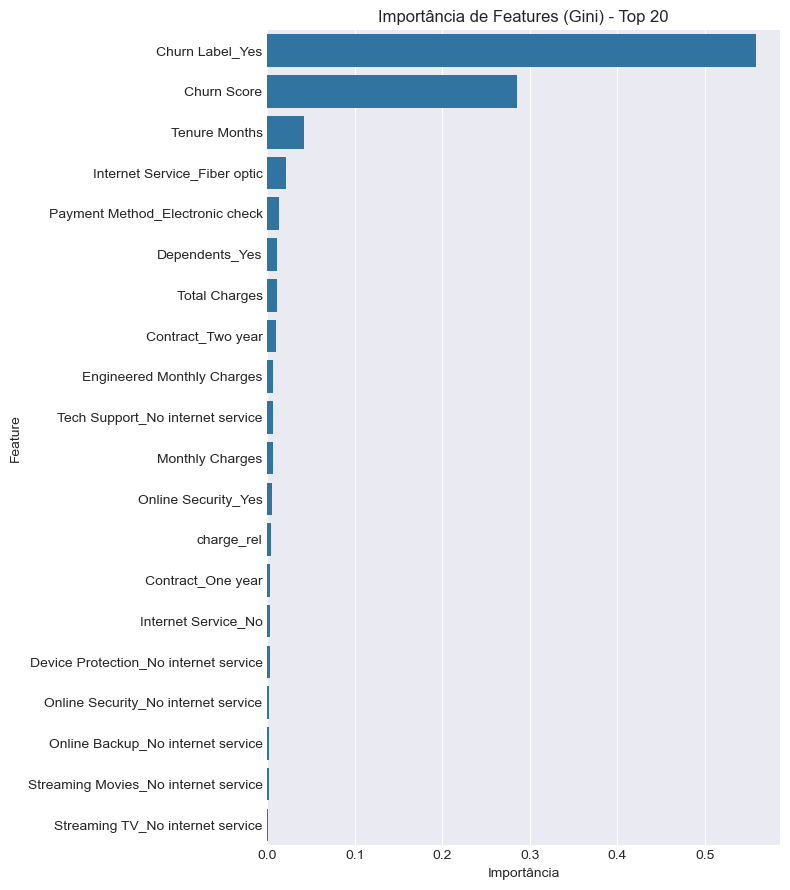

,feature,importance,std
34,Churn Label_Yes,0.335131,0.009377
6,Churn Score,0.008091,0.001625
30,Contract_Two year,0.000071,0.000213
0,Zip Code,0.000000,0.000000
25,Streaming TV_No internet service,0.000000,0.000000
26,Streaming TV_Yes,0.000000,0.000000
27,Streaming Movies_No internet service,0.000000,0.000000
28,Streaming Movies_Yes,0.000000,0.000000
29,Contract_One year,0.000000,0.000000
31,Paperless Billing_Yes,0.000000,0.000000


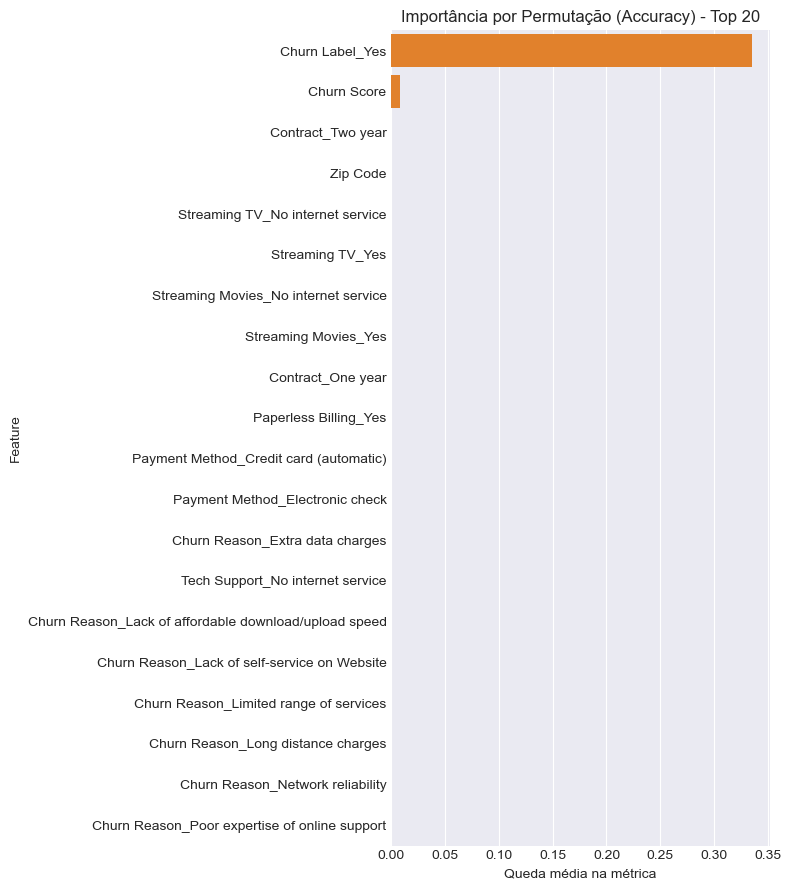

In [9]:
# Importância de features (Gini + Permutation) e persistência/log do melhor modelo
from datetime import datetime
import os
from sklearn.inspection import permutation_importance

print("== Importância de Features do Melhor Modelo ==")

# Garantias: execute a seção de tuning antes desta célula
assert "best_rf" in globals(), "best_rf não encontrado. Execute a seção de tuning antes."
assert "tuned_metrics" in globals(), "tuned_metrics não encontrado. Execute a seção de tuning antes."

# Extrair nomes de features utilizados pelo pipeline (após selector, se houver)
if hasattr(best_rf, "named_steps") and "selector" in best_rf.named_steps and hasattr(best_rf.named_steps["selector"], "get_support"):
    mask = best_rf.named_steps["selector"].get_support()
    feat_names_used = np.array(X_train.columns)[mask]
else:
    feat_names_used = np.array(X_train.columns)

# 1) Importância baseada em árvore (Gini)
model_step = best_rf.named_steps["model"] if hasattr(best_rf, "named_steps") and "model" in best_rf.named_steps else best_rf
tree_imp = getattr(model_step, "feature_importances_", None)

figs_to_log = []

if tree_imp is not None and len(tree_imp) == len(feat_names_used):
    imp_df = pd.DataFrame({"feature": feat_names_used, "importance": tree_imp}).sort_values("importance", ascending=False)
    display(imp_df.head(20))

    fig, ax = plt.subplots(figsize=(8, min(0.45*len(imp_df.head(20)), 10)))
    sns.barplot(data=imp_df.head(20), x="importance", y="feature", color="#1f77b4", ax=ax)
    ax.set_title("Importância de Features (Gini) - Top 20")
    ax.set_xlabel("Importância")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    figs_to_log.append(("feature_importance_gini_top20.png", fig))
    plt.show()
else:
    print("[Info] Modelo não expõe feature_importances_. Pulando gráfico Gini.")

# 2) Importância por permutação (Accuracy)
perm = permutation_importance(best_rf, X_test, y_test, scoring="accuracy", n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": feat_names_used,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False)
display(perm_df.head(20))

fig2, ax2 = plt.subplots(figsize=(8, min(0.45*len(perm_df.head(20)), 10)))
sns.barplot(data=perm_df.head(20), x="importance", y="feature", color="#ff7f0e", ax=ax2)
ax2.set_title("Importância por Permutação (Accuracy) - Top 20")
ax2.set_xlabel("Queda média na métrica")
ax2.set_ylabel("Feature")
plt.tight_layout()
figs_to_log.append(("feature_importance_permutation_top20.png", fig2))
plt.show()

## 7. Persistência do modelo para re-uso

O modelo será persistido na tarefa abaixo na pasta ./models do projeto.

In [10]:
# Persistência local com joblib
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

joblib_path = os.path.join(models_dir, f"best_random_forest.joblib")
joblib.dump(best_rf, joblib_path)
print(f"Modelo salvo via joblib em: {joblib_path}")

# Log no MLflow: abrir um novo run para registrar artefatos e o modelo salvo
mlflow.set_experiment("aula3_time_budget_tuning")
with mlflow.start_run(run_name="rf_importances_and_persistence"):
    # Parâmetros/metrics chave para rastreabilidade
    if 'best' in globals() and isinstance(best.get('params'), dict):
        for k, v in best["params"].items():
            mlflow.log_param(k, str(v))
    for k, v in tuned_metrics.items():
        if v is not None and not (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
            mlflow.log_metric(k.replace(" ", "_").lower(), float(v))

    # Logar figuras
    for fname, fobj in figs_to_log:
        try:
            mlflow.log_figure(fobj, fname)
        except Exception as e:
            print(f"[Aviso] Falha ao logar figura {fname}: {e}")

    # Logar o pipeline completo e o arquivo joblib como artifact
    mlflow.sklearn.log_model(best_rf, artifact_path="sklearn_model")
    mlflow.log_artifact(joblib_path, artifact_path="joblib")

print("Concluído: importâncias, persistência (joblib) e log no MLflow.")

2026/05/20 17:58:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 17:58:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo salvo via joblib em: ../models/best_random_forest.joblib
Concluído: importâncias, persistência (joblib) e log no MLflow.
